- Importing necessary libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

- Loading the dataset

In [2]:
df = pd.read_csv("day_wise.csv")

- Check the first rows

In [3]:
df.head()

,Date,Confirmed,Deaths,Recovered,Active,New cases,New deaths,New recovered,Deaths / 100 Cases,Recovered / 100 Cases,Deaths / 100 Recovered,No. of countries
0,2020-01-22,555,17,28,510,0,0,0,3.06,5.05,60.71,6
1,2020-01-23,654,18,30,606,99,1,2,2.75,4.59,60.00,8
2,2020-01-24,941,26,36,879,287,8,6,2.76,3.83,72.22,9
3,2020-01-25,1434,42,39,1353,493,16,3,2.93,2.72,107.69,11
4,2020-01-26,2118,56,52,2010,684,14,13,2.64,2.46,107.69,13


- Check dataset structure

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 188 entries, 0 to 187
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Date                    188 non-null    object 
 1   Confirmed               188 non-null    int64  
 2   Deaths                  188 non-null    int64  
 3   Recovered               188 non-null    int64  
 4   Active                  188 non-null    int64  
 5   New cases               188 non-null    int64  
 6   New deaths              188 non-null    int64  
 7   New recovered           188 non-null    int64  
 8   Deaths / 100 Cases      188 non-null    float64
 9   Recovered / 100 Cases   188 non-null    float64
 10  Deaths / 100 Recovered  188 non-null    float64
 11  No. of countries        188 non-null    int64  
dtypes: float64(3), int64(8), object(1)
memory usage: 17.8+ KB


- Select Only Necessary Columns

In [5]:
df = df[['Date', 'New cases']]

- Rename the Variable

In [6]:
df.rename(columns={'New cases': 'New_Cases'}, inplace=True)

- Convert Date to Datetime Format

In [7]:
df['Date'] = pd.to_datetime(df['Date'])

In [8]:
df.dtypes

Date         datetime64[ns]
New_Cases             int64
dtype: object

- Sort the Dataset by Date

In [9]:
df = df.sort_values(by='Date')

- Set Date as the Time Series Index

In [10]:
df.set_index('Date', inplace=True)

In [13]:
df

,New_Cases
Date,
2020-01-22,0
2020-01-23,99
2020-01-24,287
2020-01-25,493
2020-01-26,684
...,...
2020-07-23,282756
2020-07-24,281164
2020-07-25,255545


- Check Missing Values

In [14]:
df.isnull().sum()

New_Cases    0
dtype: int64

- Plotting the Time Series

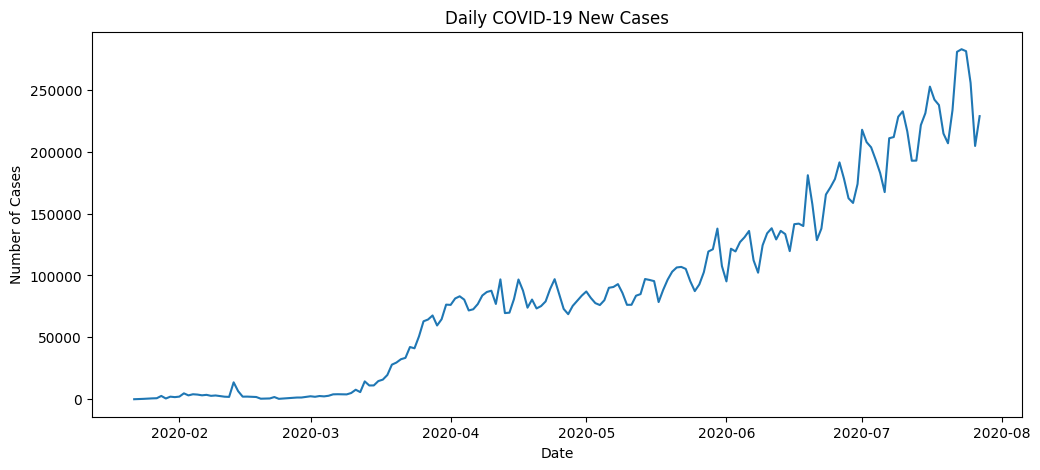

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(df['New_Cases'])
plt.title("Daily COVID-19 New Cases")
plt.xlabel("Date")
plt.ylabel("Number of Cases")
plt.show()

- Summary Statistics

In [17]:
df.describe()

,New_Cases
count,188.000000
mean,87771.021277
std,75295.293255
min,0.000000
25%,5568.500000
50%,81114.000000
75%,131502.500000
max,282756.000000


## Rolling Mean (Trend Visualization)

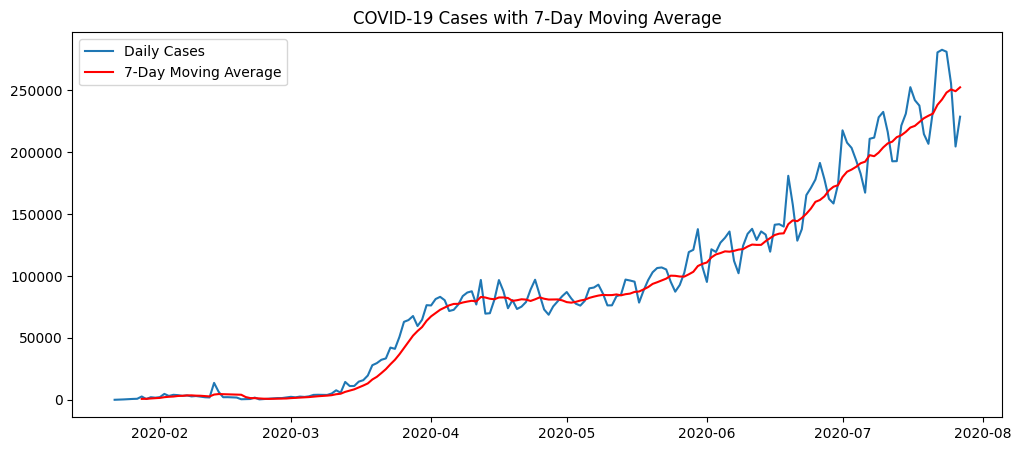

In [18]:
df['rolling_mean'] = df['New_Cases'].rolling(window=7).mean()

plt.figure(figsize=(12,5))
plt.plot(df['New_Cases'], label='Daily Cases')
plt.plot(df['rolling_mean'], color='red', label='7-Day Moving Average')
plt.legend()
plt.title("COVID-19 Cases with 7-Day Moving Average")
plt.show()

## Series Decomposition

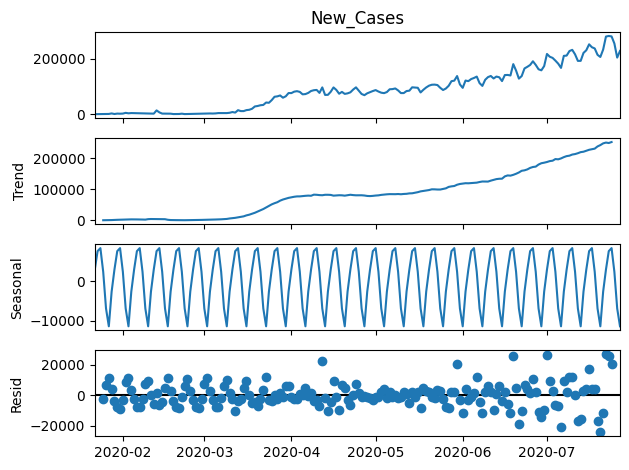

In [20]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomposition = seasonal_decompose(df['New_Cases'], model='additive', period=7)
decomposition.plot()
figsize=(12,8)
plt.show()

- For this particular Covid-19 dataset, the additive model was chosen thus; Observed = Trend + Seasonality + Residual. This was used beacuse seasonal variations remain roughly constant overtime.

## Checking for Variance

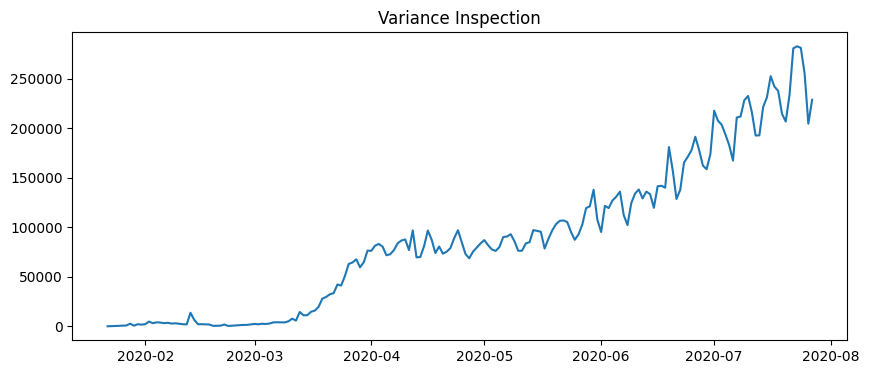

In [21]:
plt.figure(figsize=(10,4))
plt.plot(df['New_Cases'])
plt.title("Variance Inspection")
plt.show()

- This plot shows that the variance increases over time thus a need to use log transformation

## Applying Log Transformation

In [23]:
df['log_cases'] = np.log(df['New_Cases'] + 1)

## Visualizing the Transformed Series

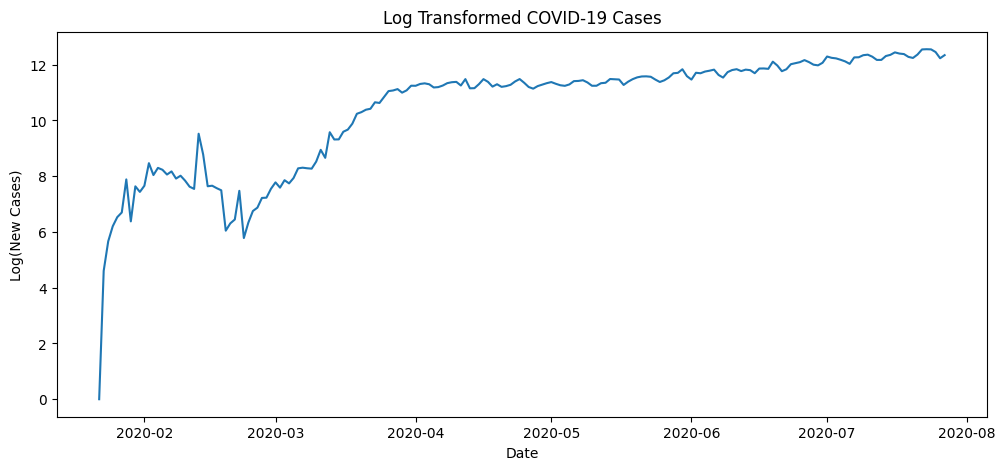

In [24]:
plt.figure(figsize=(12,5))
plt.plot(df['log_cases'])
plt.title("Log Transformed COVID-19 Cases")
plt.xlabel("Date")
plt.ylabel("Log(New Cases)")
plt.show()

- the transformation helps in compressing the large values thus reducing the increasing variance that was observed in the original series. This gives a more stable time series ready for modeling

## Comparing Before and After Transformation

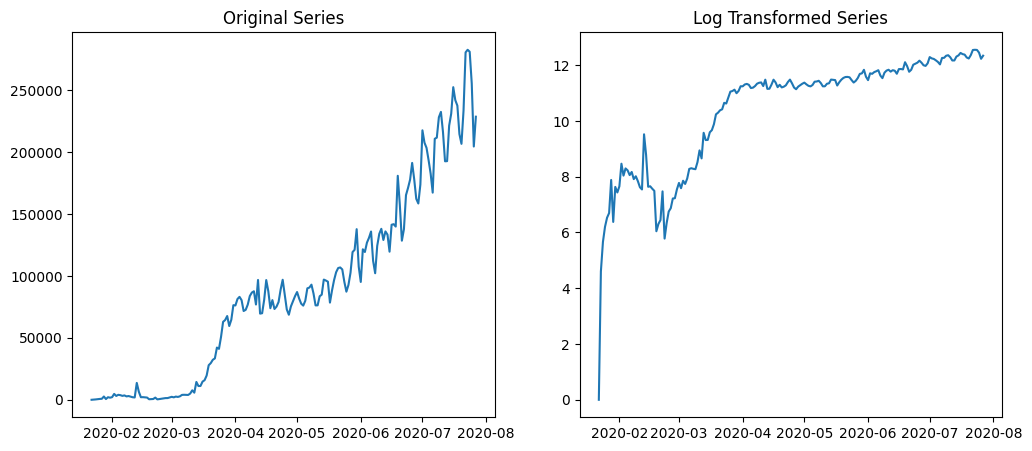

In [25]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(df['New_Cases'])
plt.title("Original Series")

plt.subplot(1,2,2)
plt.plot(df['log_cases'])
plt.title("Log Transformed Series")

plt.show()

# Milestone 2

## Stationarity Test (ADF Test)

In [27]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(df['log_cases'])

print("ADF Statistic:", result[0])
print("p-value:", result[1])
print("Critical Values:")

for key, value in result[4].items():
    print(f"{key}: {value}")

# Decision rule
if result[1] < 0.05:
    print("\nConclusion: Reject the null hypothesis.")
    print("The time series is stationary.")
else:
    print("\nConclusion: Fail to reject the null hypothesis.")
    print("The time series is non-stationary.")

ADF Statistic: -1.0617766549312084
p-value: 0.7300718499806189
Critical Values:
1%: -3.4687256239864017
5%: -2.8783961376954363
10%: -2.57575634100705

Conclusion: Fail to reject the null hypothesis.
The time series is non-stationary.


## Plotting ACF and PACF

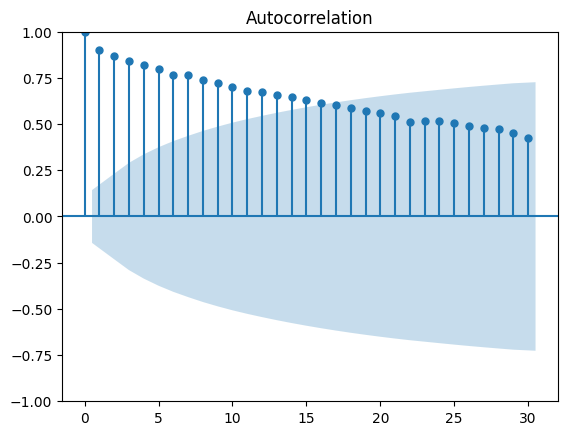

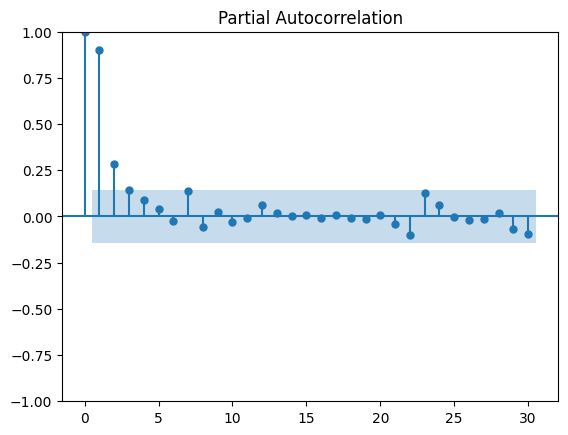

In [28]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plot_acf(df['log_cases'], lags=30)
plt.show()

plot_pacf(df['log_cases'], lags=30)
plt.show()